<a href="https://www.kaggle.com/code/namisha09/sql-project-product-customer-data-analysis?scriptVersionId=220659103" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ecommerce-data-analysis/time_dim.csv
/kaggle/input/ecommerce-data-analysis/fact_table.csv
/kaggle/input/ecommerce-data-analysis/Trans_dim.csv
/kaggle/input/ecommerce-data-analysis/item_dim.csv
/kaggle/input/ecommerce-data-analysis/store_dim.csv
/kaggle/input/ecommerce-data-analysis/customer_dim.csv


In [2]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mmohaiminulislam/ecommerce-data-analysis")

print("Path to dataset files:", path)

# List files in the input directory
input_dir = '/kaggle/input/ecommerce-data-analysis/'
files = os.listdir(input_dir)
print(files)


Path to dataset files: /kaggle/input/ecommerce-data-analysis
['time_dim.csv', 'fact_table.csv', 'Trans_dim.csv', 'item_dim.csv', 'store_dim.csv', 'customer_dim.csv']


In [3]:
import pandas as pd

# Attempt loading the CSV file with a different encoding
time_df = pd.read_csv('/kaggle/input/ecommerce-data-analysis/time_dim.csv', encoding='ISO-8859-1')
fact_df = pd.read_csv('/kaggle/input/ecommerce-data-analysis/fact_table.csv', encoding='ISO-8859-1')
trans_df = pd.read_csv('/kaggle/input/ecommerce-data-analysis/Trans_dim.csv', encoding='ISO-8859-1')
item_df = pd.read_csv('/kaggle/input/ecommerce-data-analysis/item_dim.csv', encoding='ISO-8859-1')
store_df = pd.read_csv('/kaggle/input/ecommerce-data-analysis/store_dim.csv', encoding='ISO-8859-1')
customer_df = pd.read_csv('/kaggle/input/ecommerce-data-analysis/customer_dim.csv', encoding='ISO-8859-1')

# Preview the data
print(time_df.head())
print(fact_df.head())
print(trans_df.head())
print(item_df.head())
print(store_df.head())
print(customer_df.head())

  time_key              date  hour  day      week  month quarter  year
0   T00001  20-05-2017 14:56    14   20  3rd Week      5      Q2  2017
1   T00002  30-01-2015 22:14    22   30  4th Week      1      Q1  2015
2   T00003  14-03-2020 02:34     2   14  2nd Week      3      Q1  2020
3   T00004  27-04-2018 12:19    12   27  4th Week      4      Q2  2018
4   T00005  14-04-2018 10:43    10   14  2nd Week      4      Q2  2018
  payment_key coustomer_key time_key item_key store_key  quantity   unit  \
0        P026       C004510  T049189   I00177    S00307         1     ct   
1        P022       C008967  T041209   I00248    S00595         1  rolls   
2        P030       C007261   T03633   I00195    S00496         8     ct   
3        P032       C007048  T084631   I00131     S0086         8     ct   
4        P014       C006430  T071276   I00050    S00488         8   cans   

   unit_price  total_price  
0        35.0         35.0  
1        26.0         26.0  
2        12.5        100.0  
3

In [4]:
import sqlite3

# Create an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Load DataFrames into SQL tables
time_df.to_sql('time_dim', conn, index=False, if_exists='replace')
fact_df.to_sql('fact_table', conn, index=False, if_exists='replace')
trans_df.to_sql('trans_dim', conn, index=False, if_exists='replace')
item_df.to_sql('item_dim', conn, index=False, if_exists='replace')
store_df.to_sql('store_dim', conn, index=False, if_exists='replace')
customer_df.to_sql('customer_dim', conn, index=False, if_exists='replace')

# Verify by checking the tables
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)
print(tables)

           name
0      time_dim
1    fact_table
2     trans_dim
3      item_dim
4     store_dim
5  customer_dim


In [5]:
# Total sales per product 
query = """
SELECT 
    item_dim.item_name, 
    SUM(fact_table.quantity * item_dim.unit_price) AS total_sales
FROM 
    fact_table 
JOIN 
    item_dim 
ON 
    fact_table.item_key = item_dim.item_key
GROUP BY 
    item_dim.item_name
ORDER BY 
    total_sales DESC
LIMIT 10;
"""

# Running the query and storing the results in a DataFrame
top_products = pd.read_sql_query(query, conn)

# Display the results
print(top_products)

                               item_name  total_sales
0                          Red Bull 12oz    1305700.0
1    K Cups Daily Chef Columbian Supremo    1245394.0
2  K Cups Original Donut Shop Med. Roast    1188843.0
3      K Cups Dunkin Donuts Medium Roast    1109760.0
4    Muscle Milk Protein Shake Van. 11oz    1050924.0
5        K Cups Folgers Lively Columbian    1042406.0
6                        Honey Packets      1012995.0
7         K Cups  Starbuck's Pike Place     995456.0
8        K Cups Organic Breakfast Blend     957516.0
9          K Cups - McCafe Premium Roast     956886.0


<ipython-input-6-0a54bce274b0>:11: UserWarning: Glyph 150 (\x96) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


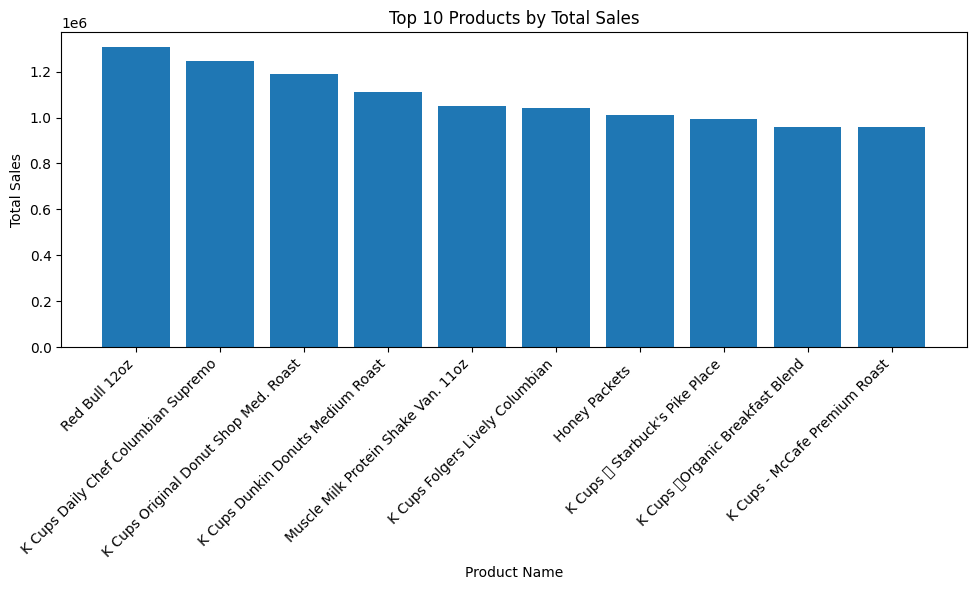

In [6]:
# Plot the data

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(top_products['item_name'], top_products['total_sales'])
plt.xticks(rotation=45, ha="right")
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [7]:
# Top Customers by Total Spend
query1 = """
SELECT 
    customer_dim.name, 
    SUM(fact_table.total_price) AS total_spend
FROM 
    fact_table
JOIN 
    customer_dim
ON 
    fact_table.coustomer_key = customer_dim.coustomer_key
GROUP BY 
    customer_dim.name
ORDER BY 
    total_spend DESC
LIMIT 10;
"""
# Running the query and storing the results in a DataFrame
top_customers = pd.read_sql_query(query1, conn)

# Display the results
print(top_customers)


       name  total_spend
0     pooja   2109800.75
1     jyoti   1331696.25
2      neha    996121.00
3    sunita    915543.75
4    poonam    914285.25
5  priyanka    819243.25
6     seema    813087.75
7     suman    748327.25
8     komal    698672.75
9     mamta    688649.50


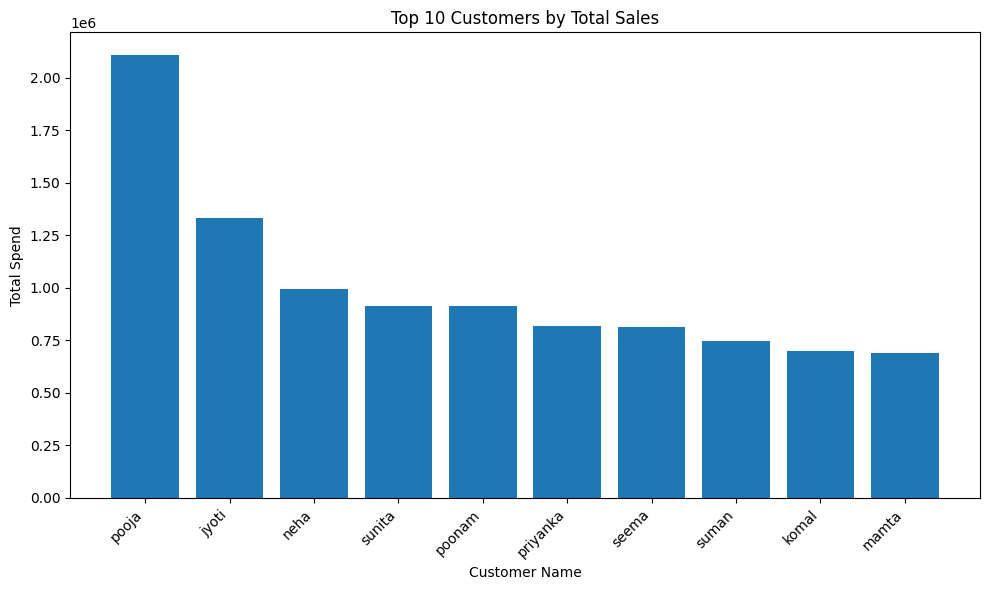

In [8]:
# Plot the data

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(top_customers['name'], top_customers['total_spend'])
plt.xticks(rotation=45, ha="right")
plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Customer Name')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()

In [9]:
#Sales by Region (Store Analysis)
query2 = """SELECT 
    store_dim.district, 
    SUM(fact_table.total_price) AS total_sales
FROM 
    fact_table
JOIN 
    store_dim
ON 
    fact_table.store_key = store_dim.store_key
GROUP BY 
    store_dim.district
ORDER BY 
    total_sales DESC
LIMIT 10;  -- Get top 10 districts by sales
"""
# Running the query and storing the results in a DataFrame
top_region = pd.read_sql_query(query2, conn)

# Display the results
print(top_region)

      district  total_sales
0        DHAKA  23597621.00
1   CHITTAGONG   7292985.50
2       KHULNA   4081283.75
3     RAJSHAHI   3756454.50
4      BARISAL   2897237.75
5      COMILLA   2286898.25
6  KISHOREGONJ   1895395.50
7   MYMENSINGH   1885230.50
8     DINAJPUR   1871005.75
9      TANGAIL   1774650.25


In [10]:
#Sales by Month (Time-Based Analysis)
query3 = """
SELECT 
    time_dim.month, 
    SUM(fact_table.total_price) AS total_sales
FROM 
    fact_table
JOIN 
    time_dim
ON 
    fact_table.time_key = time_dim.time_key
GROUP BY 
    time_dim.month
ORDER BY 
    total_sales DESC;
"""
# Running the query and storing the results in a DataFrame
sales_bymonth = pd.read_sql_query(query3, conn)

# Display the results
print(sales_bymonth)

    month  total_sales
0       5   9078002.50
1       7   9046580.00
2       1   9042244.00
3       3   8939152.00
4       8   8929475.25
5      12   8923480.50
6      10   8902783.75
7       9   8724326.50
8      11   8680026.00
9       6   8556853.00
10      4   8504634.75
11      2   8073877.50


In [11]:
#Total Sales by Store

query4 = """
SELECT 
    store_dim.store_key,
    store_dim.upazila,
    SUM(fact_table.total_price) AS total_store_sales
FROM 
    fact_table
JOIN 
    store_dim 
ON 
    fact_table.store_key = store_dim.store_key
GROUP BY 
    store_dim.store_key, store_dim.upazila
ORDER BY 
    total_store_sales DESC
LIMIT 10;
"""

# Running the query and storing the results in a DataFrame
sales_bystore = pd.read_sql_query(query4, conn)

# Display the results
print(sales_bystore)

  store_key        upazila  total_store_sales
0     S0010           JURI          159409.00
1    S00601    DARUS SALAM          158027.50
2    S00328       SHIBCHAR          157692.00
3     S0039       BIRAMPUR          157483.00
4     S0080           BODA          157377.50
5    S00357         BANDAR          157243.50
6    S00411        AKHAURA          156979.50
7    S00708      PAHARTALI          156793.75
8    S00687  UTTARA  PURBA          156767.75
9    S00266        PALLABI          156651.50


In [12]:
#Monthly Sales Trend Analysis

query5 = """
SELECT 
    time_dim.year, 
    time_dim.month, 
    SUM(fact_table.total_price) AS monthly_sales
FROM 
    fact_table
JOIN 
    time_dim 
ON 
    fact_table.time_key = time_dim.time_key
GROUP BY 
    time_dim.year, time_dim.month
ORDER BY 
    time_dim.year, time_dim.month
LIMIT 15;
"""
# Running the query and storing the results in a DataFrame
sales_bymonthtrend = pd.read_sql_query(query5, conn)

# Display the results
print(sales_bymonthtrend)

    year  month  monthly_sales
0   2014      1      496549.25
1   2014      2     1122547.00
2   2014      3     1262435.75
3   2014      4     1245142.50
4   2014      5     1268770.50
5   2014      6     1240771.75
6   2014      7     1317296.00
7   2014      8     1293211.00
8   2014      9     1279444.25
9   2014     10     1299793.50
10  2014     11     1211569.75
11  2014     12     1297200.00
12  2015      1     1239765.00
13  2015      2     1157159.75
14  2015      3     1296063.75


In [13]:
#Customer Purchase Frequency
query6 = """
SELECT 
    customer_dim.name, 
    COUNT(fact_table.payment_key) AS purchase_frequency
FROM 
    fact_table
JOIN 
    customer_dim 
ON 
    fact_table.coustomer_key = customer_dim.coustomer_key
GROUP BY 
    customer_dim.name
ORDER BY 
    purchase_frequency DESC
LIMIT 10;
"""
# Running the query and storing the results in a DataFrame
purchase_frequency = pd.read_sql_query(query6, conn)

# Display the results
print(purchase_frequency)

       name  purchase_frequency
0     pooja               20173
1     jyoti               12696
2      neha                9419
3    poonam                8727
4    sunita                8648
5  priyanka                7733
6     seema                7610
7     suman                7082
8     komal                6668
9     mamta                6576


In [14]:
#Top Selling Product Categories
query7 = """
SELECT 
    item_dim.desc AS product_category,
    SUM(fact_table.quantity) AS total_quantity_sold
FROM 
    fact_table
JOIN 
    item_dim 
ON 
    fact_table.item_key = item_dim.item_key
GROUP BY 
    item_dim.desc
ORDER BY 
    total_quantity_sold DESC
LIMIT 5;
"""
# Running the query and storing the results in a DataFrame
top_product = pd.read_sql_query(query7, conn)

# Display the results
print(top_product)

              product_category  total_quantity_sold
0           a. Beverage - Soda               659916
1               Food - Healthy               655553
2                 Food - Chips               477884
3  a. Beverage Sparkling Water               475022
4             Kitchen Supplies               435177


In [15]:
#Payment Method Preferences
query8 = """
SELECT 
    payment_key, 
    COUNT(payment_key) AS payment_count
FROM 
    fact_table
GROUP BY 
    payment_key
ORDER BY 
    payment_count DESC
LIMIT 5;
"""
# Running the query and storing the results in a DataFrame
pay_preference = pd.read_sql_query(query8, conn)

# Display the results
print(pay_preference)

  payment_key  payment_count
0        P002          26046
1        P032          25964
2        P021          25887
3        P038          25865
4        P029          25853
